# Clasificación de arritmias cardíacas usando señales ECG

Este notebook desarrolla un flujo completo para clasificar latidos cardíacos a partir de señales de electrocardiograma. Se trabaja con la base publica **MIT-BIH Arrhythmia Database** y se comparan tres modelos clásicos de aprendizaje automático: **KNN**, **SVM** y **Random Forest**.


## 1. Importación de librerías

Se cargan las librerías necesarias para leer los registros ECG, procesar datos, entrenar modelos y generar gráficas.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wfdb

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 2. Configuración del experimento

Parámetros principales del experimento: registros a utilizar, clases consideradas, estrategia de división y balanceo del conjunto de entrenamiento.


In [2]:
DATA_DIR = Path("data/mitdb")
OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# La clase de latidos Q agrupa latidos "paced", desconocidos o no clasificables; por lo tanto se excluye del experimento principal.
INCLUDE_Q_CLASS = False
MIN_SAMPLES_PER_CLASS = 30

# La opción de split elegida es "stratified_beat" ya que conserva la proporción de clases; otra opción es "record_group" donde se divide por grupos de registros, 
# pero esto puede llevar a una distribución de clases muy desigual entre entrenamiento y prueba.
SPLIT_STRATEGY = "stratified_beat"
TEST_SIZE = 0.30

# El balanceo se aplica solo al entrenamiento para no alterar la distribución real de prueba.
BALANCE_TRAINING_DATA = True
MAX_SAMPLES_PER_CLASS_AFTER_BALANCING = 3000

# Todos los registros disponibles de MIT-BIH Arrhythmia Database.
full_records = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115", "116", "117", "118", "119", "121",
    "122", "123", "124", "200", "201", "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214", "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231", "232", "233", "234"
]

print(full_records)

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


## 3. Descarga automatica de MIT-BIH

Si los registros no existen localmente, se descargan desde PhysioNet. Si ya estan en la carpeta de datos, el notebook continua sin repetir la descarga.


In [3]:
def download_mitdb(records, data_dir):
    """Descarga registros seleccionados de MIT-BIH si no están disponibles localmente."""
    data_dir.mkdir(parents=True, exist_ok=True)
    missing_records = [record for record in records if not (data_dir / f"{record}.hea").exists()]

    if missing_records:
        print(f"Descargando {len(missing_records)} registros desde PhysioNet...")
        wfdb.dl_database("mitdb", dl_dir=str(data_dir), records=missing_records)
    else:
        print("Todos los registros seleccionados ya estan disponibles localmente.")


download_mitdb(full_records, DATA_DIR)

Descargando 48 registros desde PhysioNet...
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 

## 4. Etiquetas y clases AAMI

Las anotaciones originales de MIT-BIH incluyen símbolos detallados para distintos tipos de latidos. Para este proyecto se agrupan en clases AAMI simplificadas:

- `N`: latidos normales o de conducción similar.
- `S`: latidos supraventriculares ectópicos.
- `V`: latidos ventriculares ectópicos.
- `F`: fusión de latido normal y ventricular.
- `Q`: latidos desconocidos, paced o no clasificables.

La clase `Q` se deja fuera del modelado principal porque mezcla casos con interpretación distinta. Esta decision mantiene el problema mas enfocado en las clases de arritmia usadas para la comparación de modelos.

In [4]:
# Mapeo de símbolos MIT-BIH a clases AAMI simplificadas.
# Esto se hace para reducir las etiquetas poco frecuentes en el dataset, lo que permite trabajar con un problema de clasificación multiclase mas manejable.
AAMI_LABELS = {
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    "A": "S", "a": "S", "J": "S", "S": "S",
    "V": "V", "E": "V",
    "F": "F",
    "/": "Q", "f": "Q", "Q": "Q",
}

CLASS_ORDER = ["N", "S", "V", "F", "Q"]

In [5]:
label_mapping_df = (
    pd.DataFrame(
        [{"mit_bih_symbol": symbol, "aami_class": aami_class} for symbol, aami_class in AAMI_LABELS.items()]
    )
    .sort_values(["aami_class", "mit_bih_symbol"])
    .reset_index(drop=True)
)

display(label_mapping_df)

,mit_bih_symbol,aami_class
0,F,F
1,L,N
2,N,N
3,R,N
4,e,N
5,j,N
6,/,Q
7,Q,Q
8,f,Q
9,A,S


## 5. Segmentación y extracción de características

Cada anotación se usa como referencia para tomar una ventana de señal alrededor del latido. Después se calculan características de amplitud, variación, energía, morfología e intervalos RR.

In [6]:
def select_ecg_channel(record):
    """Selecciona el canal MLII cuando existe; si no, usa el primer canal disponible."""
    if "MLII" in record.sig_name:
        return record.sig_name.index("MLII")
    return 0


def extract_features(segment, previous_rr, next_rr):
    """Calcula características numéricas y morfológicas a partir de un segmento ECG."""
    segment = np.asarray(segment, dtype=float)

    # Se centra cada latido para reducir diferencias de linea base entre registros.
    centered = segment - np.median(segment)
    normalized = centered / (np.std(centered) + 1e-8)
    diff = np.diff(centered)

    # Estos puntos resumen la forma del latido sin usar todo el segmento como entrada.
    morphology_indexes = np.linspace(0, len(normalized) - 1, 30).astype(int)

    # Se calculan características estadísticas, de energía, de ritmo y de forma del latido.
    features = {
        "mean": np.mean(centered),
        "std": np.std(centered),
        "min": np.min(centered),
        "max": np.max(centered),
        "range": np.ptp(centered),
        "median": np.median(centered),
        "q25": np.percentile(centered, 25),
        "q75": np.percentile(centered, 75),
        "energy": np.sum(centered ** 2) / len(centered),
        "abs_mean": np.mean(np.abs(centered)),
        "positive_area": np.sum(np.clip(centered, 0, None)),
        "negative_area": np.sum(np.abs(np.clip(centered, None, 0))),
        "max_abs": np.max(np.abs(centered)),
        "diff_mean": np.mean(diff),
        "diff_std": np.std(diff),
        "diff_max": np.max(diff),
        "diff_min": np.min(diff),
        "zero_crossings": np.sum(np.diff(np.signbit(centered)) != 0),
        "previous_rr": previous_rr,
        "next_rr": next_rr,
        "rr_ratio": previous_rr / next_rr if next_rr > 0 else 0.0,
    }

    # Las variables morphology_00 a morphology_29 resumen la forma del latido:
    # cada una almacena la amplitud normalizada en un punto distribuido a lo largo del segmento ECG.
    for point_index, signal_index in enumerate(morphology_indexes):
        features[f"morphology_{point_index:02d}"] = normalized[signal_index]

    return features


def build_beat_dataset(records, data_dir, before_seconds=0.25, after_seconds=0.45):
    """Construye una tabla de características por latido a partir de registros MIT-BIH."""
    rows = []

    for record_id in records:
        record_path = str(data_dir / record_id)
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, "atr")

        fs = int(record.fs) # Frecuencia de muestreo
        before = int(before_seconds * fs) # Cantidad de muestras a incluir antes del latido
        after = int(after_seconds * fs) # Cantidad de muestras a incluir después del latido
        channel_index = select_ecg_channel(record) # Selección del canal ECG a usar
        signal = record.p_signal[:, channel_index] # Señal ECG del canal seleccionado

        samples = np.asarray(annotation.sample) # Índices de muestra donde se encuentran los latidos anotados
        symbols = np.asarray(annotation.symbol) # Símbolos de anotación que indican el tipo de latido

        # Se itera sobre cada latido anotado para extraer características y construir filas de la tabla.
        for index, (sample, symbol) in enumerate(zip(samples, symbols)):
            label = AAMI_LABELS.get(symbol)
            if label is None:
                continue

            # Se descartan latidos incompletos al inicio o al final del registro.
            start = sample - before
            end = sample + after
            if start < 0 or end > len(signal):
                continue

            # Los intervalos RR agregan información de ritmo ademas de la forma del latido.
            previous_rr = (sample - samples[index - 1]) / fs if index > 0 else np.nan
            next_rr = (samples[index + 1] - sample) / fs if index < len(samples) - 1 else np.nan
            if np.isnan(previous_rr) or np.isnan(next_rr) or previous_rr <= 0 or next_rr <= 0:
                continue

            segment = signal[start:end]
            features = extract_features(segment, previous_rr, next_rr)
            features.update({
                "record_id": record_id,
                "symbol": symbol,
                "label": label,
                "sample": int(sample),
            })
            rows.append(features)

    return pd.DataFrame(rows)

# Se construye el dataset de latidos a partir de los registros seleccionados.
beats_df = build_beat_dataset(full_records, DATA_DIR)
beats_df.head()

,mean,std,min,max,range,median,q25,q75,energy,abs_mean,...,morphology_24,morphology_25,morphology_26,morphology_27,morphology_28,morphology_29,record_id,symbol,label,sample
0,0.025754,0.200791,-0.1925,1.2825,1.475,2.775558e-17,-0.06250,0.0375,0.040980,0.092659,...,0.087155,0.112057,0.161860,0.186761,0.136958,0.087155,100,N,N,370
1,0.027996,0.182994,-0.2100,1.3200,1.530,0.000000e+00,-0.04625,0.0450,0.034271,0.079623,...,0.273233,0.327880,0.191263,0.218587,0.109293,0.054647,100,N,N,662
2,0.039385,0.173628,-0.2750,1.2300,1.505,0.000000e+00,-0.02000,0.0700,0.031698,0.075734,...,0.575943,0.345566,0.431958,0.316769,0.287972,0.230377,100,N,N,946
3,0.028194,0.164246,-0.2000,1.1850,1.385,0.000000e+00,-0.04000,0.0550,0.027772,0.076567,...,0.273980,0.365307,0.395749,0.395749,0.213096,0.182653,100,N,N,1231
4,0.026726,0.174961,-0.1925,1.2375,1.430,0.000000e+00,-0.05750,0.0625,0.031326,0.086290,...,0.328644,0.357222,0.471533,0.357222,0.242911,0.214333,100,N,N,1515


In [7]:
def prepare_modeling_dataset(beats_df):
    """Filtra clases no deseadas o con soporte insuficiente para un modelado adecuado."""
    model_df = beats_df.copy()

    # La clase Q se puede incluir cambiando INCLUDE_Q_CLASS, pero no se usa en el experimento principal.
    if not INCLUDE_Q_CLASS:
        model_df = model_df[model_df["label"] != "Q"].copy()

    # Evita entrenar o reportar métricas sobre clases con muy pocos ejemplos.
    class_counts = model_df["label"].value_counts()
    valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
    model_df = model_df[model_df["label"].isin(valid_classes)].copy()

    return model_df


model_df = prepare_modeling_dataset(beats_df)

print(f"Latidos procesados antes del filtrado: {len(beats_df):,}")
print(f"Latidos disponibles para modelado: {len(model_df):,}")

print("\nDistribución original:")
display(beats_df["label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int).to_frame("count"))

print("\nDistribución usada para modelado:")
display(model_df["label"].value_counts().reindex(CLASS_ORDER).dropna().astype(int).to_frame("count"))

print("\nDistribución por registro y clase:")
display(pd.crosstab(model_df["record_id"], model_df["label"]))

Latidos procesados antes del filtrado: 109,432
Latidos disponibles para modelado: 101,394

Distribución original:


,count
label,
N,90578
S,2779
V,7235
F,802
Q,8038



Distribución usada para modelado:


,count
label,
N,90578
S,2779
V,7235
F,802



Distribución por registro y clase:


label,F,N,S,V
record_id,,,,
100,0,2237,33,1
101,0,1858,3,0
102,0,99,0,4
103,0,2081,2,0
104,0,163,0,2
105,0,2525,0,41
106,0,1506,0,520
107,0,0,0,59
108,2,1738,4,17


## 6. Análisis exploratorio breve

Antes de entrenar los modelos, se analiza la distribución de clases. Este paso es importante porque los registros ECG suelen presentar desbalance, ya que los latidos normales aparecen con mucha más frecuencia que algunas clases de arritmia.

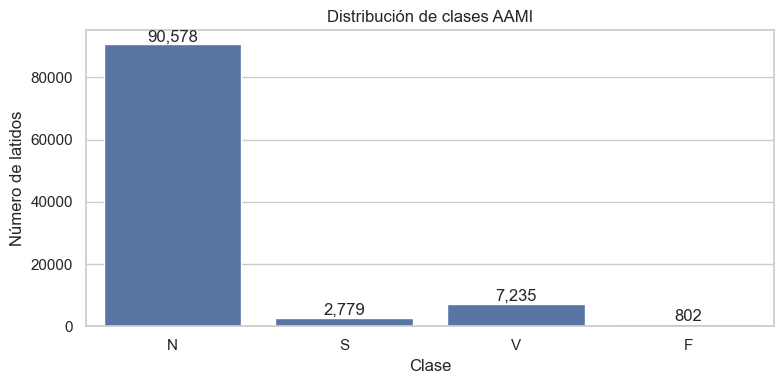

In [8]:
plt.figure(figsize=(8, 4))
sns.countplot(data=model_df, x="label", order=[label for label in CLASS_ORDER if label in model_df["label"].unique()])

# Etiquetas de conteo encima de cada barra.
for p in plt.gca().patches:
    count = int(p.get_height())
    if count > 0:
        plt.text(p.get_x() + p.get_width() / 2, p.get_height(), f"{count:,}", ha="center", va="bottom")

plt.title("Distribución de clases AAMI")
plt.xlabel("Clase")
plt.ylabel("Número de latidos")
plt.tight_layout()

# Se guarda en outputs/figures y también con el nombre usado en versiones anteriores del proyecto.
plt.savefig(FIGURES_DIR / "class_distribution_count.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Exploración visual de los datos

Las siguientes gráficas ayudan a revisar la señal, los segmentos de latidos y algunas diferencias entre clases. También se guardan como archivos para poder usarlas en la presentación o en el reporte.

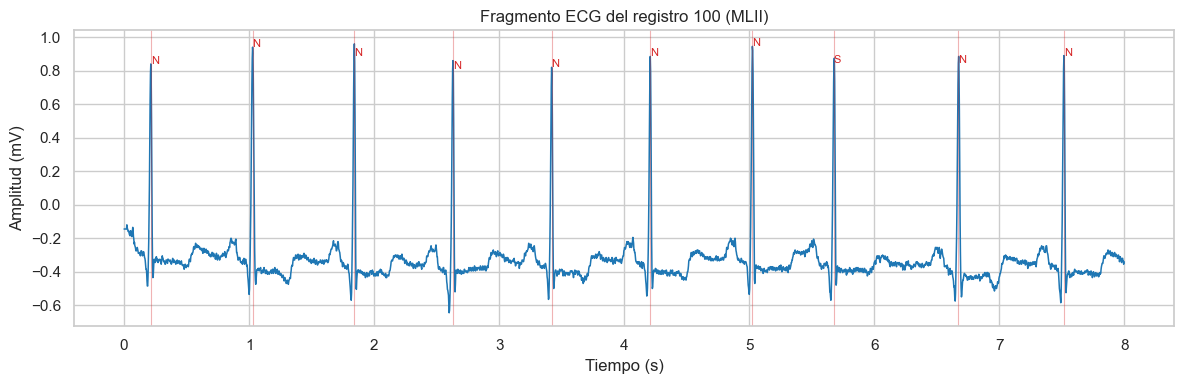

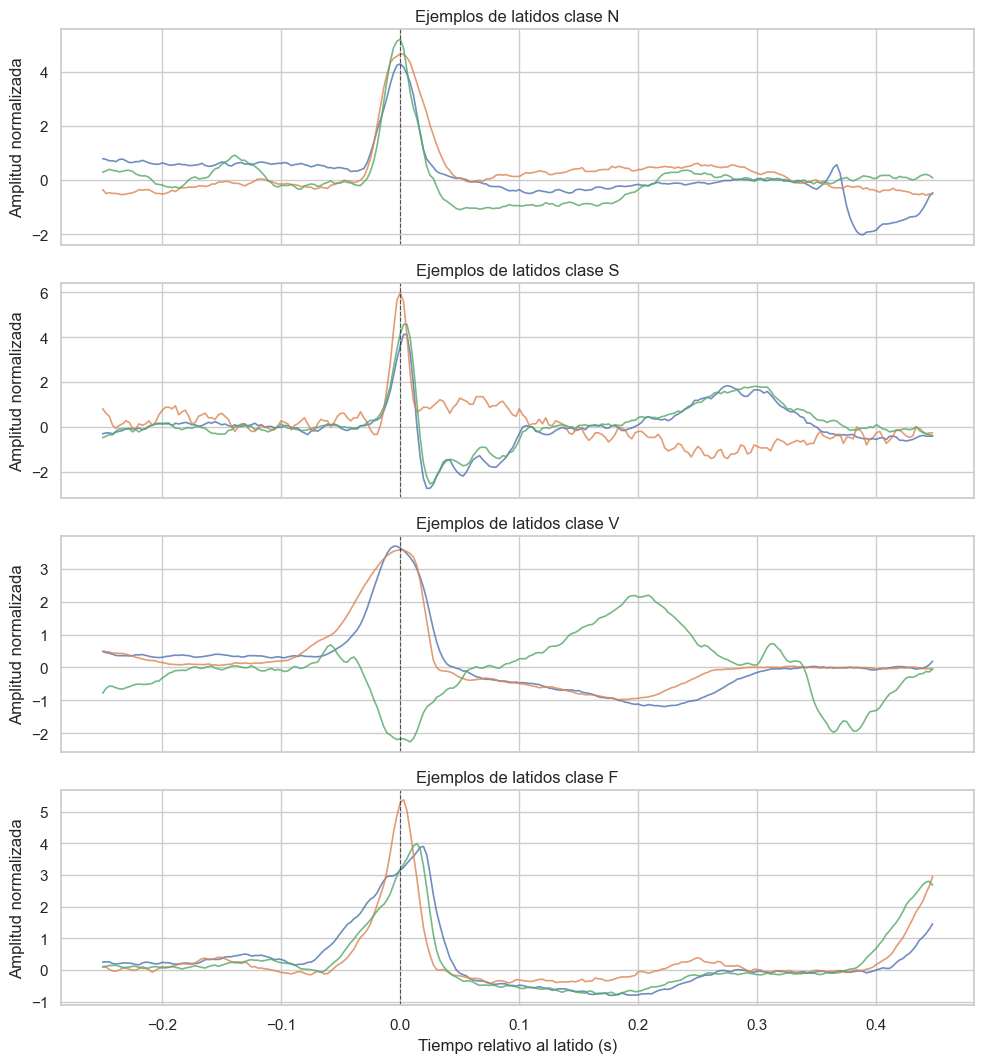

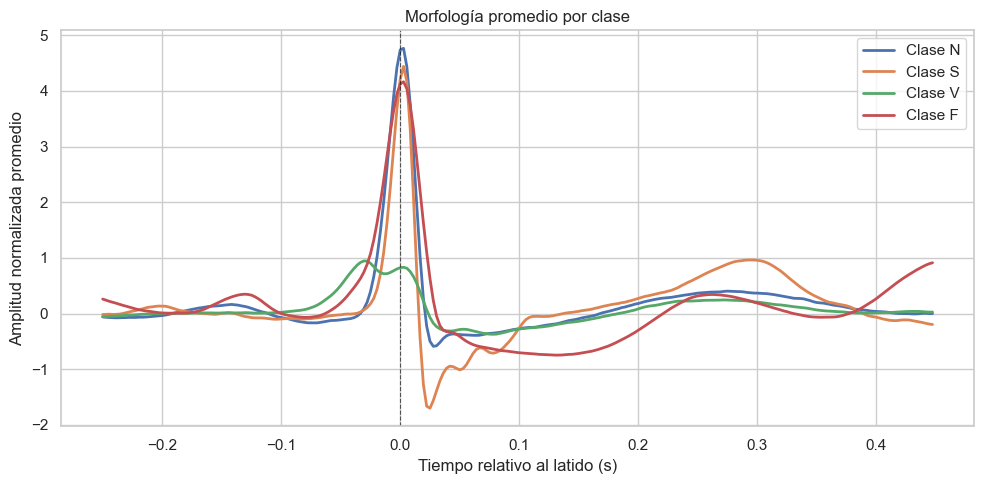

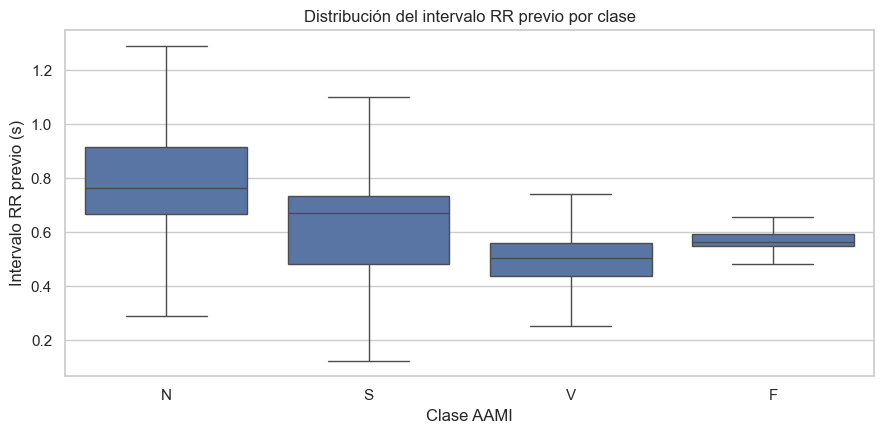

In [9]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def read_record_signal(record_id, data_dir=DATA_DIR):
    """Lee un registro ECG y devuelve la señal seleccionada, anotaciones y frecuencia de muestreo."""
    record_path = str(data_dir / record_id)
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")
    channel_index = select_ecg_channel(record)
    signal = record.p_signal[:, channel_index]
    return signal, annotation, int(record.fs), record.sig_name[channel_index]


def get_beat_segment(row, before_seconds=0.25, after_seconds=0.45):
    """Reconstruye el segmento ECG de un latido usando record_id y sample."""
    signal, _, fs, _ = read_record_signal(row["record_id"])
    before = int(before_seconds * fs)
    after = int(after_seconds * fs)
    sample = int(row["sample"])
    start = sample - before
    end = sample + after
    segment = signal[start:end]
    time_axis = (np.arange(len(segment)) - before) / fs
    return time_axis, segment


def normalize_segment(segment):
    """Centra y escala un segmento para comparar morfologías."""
    centered = segment - np.median(segment)
    return centered / (np.std(centered) + 1e-8)


def plot_ecg_record_sample(record_id=None, seconds=8):
    """Gráfica un fragmento ECG y marca las anotaciones incluidas en la ventana."""
    if record_id is None:
        record_id = model_df["record_id"].iloc[0]

    signal, annotation, fs, channel_name = read_record_signal(record_id)
    end = min(int(seconds * fs), len(signal))
    time_axis = np.arange(end) / fs

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(time_axis, signal[:end], linewidth=1.1, color="#1f77b4")

    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if sample >= end:
            break
        mapped_label = AAMI_LABELS.get(symbol)
        if mapped_label is None:
            continue
        ax.axvline(sample / fs, color="#d62728", alpha=0.35, linewidth=0.8)
        ax.text(sample / fs, signal[sample], mapped_label, fontsize=8, color="#d62728")

    ax.set_title(f"Fragmento ECG del registro {record_id} ({channel_name})")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud (mV)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "ecg_record_sample.png", dpi=160, bbox_inches="tight")
    plt.show()


def plot_example_beats_by_class(max_examples=3):
    """Gráfica segmentos individuales normalizados para cada clase disponible."""
    classes = [label for label in CLASS_ORDER if label in model_df["label"].unique()]
    fig, axes = plt.subplots(len(classes), 1, figsize=(10, 2.7 * len(classes)), sharex=True)
    if len(classes) == 1:
        axes = [axes]

    for ax, label in zip(axes, classes):
        examples = model_df[model_df["label"] == label].sample(
            n=min(max_examples, (model_df["label"] == label).sum()),
            random_state=RANDOM_STATE,
        )
        for _, row in examples.iterrows():
            time_axis, segment = get_beat_segment(row)
            ax.plot(time_axis, normalize_segment(segment), alpha=0.8, linewidth=1.2)
        ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.set_title(f"Ejemplos de latidos clase {label}")
        ax.set_ylabel("Amplitud normalizada")

    axes[-1].set_xlabel("Tiempo relativo al latido (s)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "example_beats_by_class.png", dpi=160, bbox_inches="tight")
    plt.show()


def plot_average_beat_by_class(max_segments_per_class=300):
    """Gráfica la morfología promedio normalizada de cada clase."""
    plt.figure(figsize=(10, 5))

    for label in [label for label in CLASS_ORDER if label in model_df["label"].unique()]:
        rows = model_df[model_df["label"] == label].sample(
            n=min(max_segments_per_class, (model_df["label"] == label).sum()),
            random_state=RANDOM_STATE,
        )
        segments = []
        time_axis = None
        for _, row in rows.iterrows():
            time_axis, segment = get_beat_segment(row)
            segments.append(normalize_segment(segment))
        mean_segment = np.mean(np.vstack(segments), axis=0)
        plt.plot(time_axis, mean_segment, linewidth=2, label=f"Clase {label}")

    plt.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.title("Morfología promedio por clase")
    plt.xlabel("Tiempo relativo al latido (s)")
    plt.ylabel("Amplitud normalizada promedio")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "average_beat_by_class.png", dpi=160, bbox_inches="tight")
    plt.show()


def plot_rr_distribution():
    """Muestra la distribución del intervalo RR previo por clase."""
    plt.figure(figsize=(9, 4.5))
    sns.boxplot(
        data=model_df,
        x="label",
        y="previous_rr",
        order=[label for label in CLASS_ORDER if label in model_df["label"].unique()],
        showfliers=False,
    )
    plt.title("Distribución del intervalo RR previo por clase")
    plt.xlabel("Clase AAMI")
    plt.ylabel("Intervalo RR previo (s)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "rr_distribution_by_class.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_ecg_record_sample()
plot_example_beats_by_class()
plot_average_beat_by_class()
plot_rr_distribution()

## 8. División de datos

La evaluación principal usa una division estratificada por latido para conservar la proporción de clases en entrenamiento y prueba. Esta estrategia permite comparar modelos de forma estable.

También se deja disponible la opción `record_group`, que separa registros completos. Esa evaluación es mas exigente porque se acerca mas a probar generalización entre pacientes, aunque puede reducir el desempeño si algunas clases quedan poco representadas.

In [10]:
metadata_columns = {"record_id", "symbol", "label", "sample"}
feature_columns = [column for column in model_df.columns if column not in metadata_columns]

X = model_df[feature_columns].fillna(0)
y = model_df["label"]
groups = model_df["record_id"]

# La estrategia de división se controla desde la celda de configuración.
if SPLIT_STRATEGY == "record_group":
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_index, test_index = next(splitter.split(X, y, groups=groups))
elif SPLIT_STRATEGY == "stratified_beat":
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_index, test_index = next(splitter.split(X, y))
else:
    raise ValueError("SPLIT_STRATEGY debe ser 'stratified_beat' o 'record_group'.")

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print(f"Estrategia de división: {SPLIT_STRATEGY}")
print(f"Registros de entrenamiento: {sorted(model_df.iloc[train_index]['record_id'].unique())}")
print(f"Registros de prueba: {sorted(model_df.iloc[test_index]['record_id'].unique())}")
print(f"Latidos de entrenamiento: {len(X_train):,}")
print(f"Latidos de prueba: {len(X_test):,}")

split_distribution = pd.DataFrame({
    "train": y_train.value_counts(),
    "test": y_test.value_counts(),
}).fillna(0).astype(int).reindex(CLASS_ORDER).dropna(how="all")
display(split_distribution)

Estrategia de división: stratified_beat
Registros de entrenamiento: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
Registros de prueba: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
Latidos de entrenamiento: 70,975
Latidos de prueba: 30,419


,train,test
label,,
N,63404.0,27174.0
S,1945.0,834.0
V,5065.0,2170.0
F,561.0,241.0


## 9. Entrenamiento de modelos

Se entrenan KNN, SVM y Random Forest. KNN y SVM usan estandarización porque dependen de la escala de las variables. Antes de entrenar se balancea el conjunto de entrenamiento para reducir el sesgo hacia la clase mayoritaria.


In [11]:
def balance_training_set(X_train, y_train):
    """Balancea clases por remuestreo solo dentro del conjunto de entrenamiento."""
    if not BALANCE_TRAINING_DATA:
        return X_train, y_train

    train_df = X_train.copy()
    train_df["label"] = y_train.values
    class_counts = train_df["label"].value_counts()
    target_count = min(class_counts.max(), MAX_SAMPLES_PER_CLASS_AFTER_BALANCING)

    balanced_parts = []
    for label, group in train_df.groupby("label"):
        # Si una clase tiene pocos ejemplos, se permite muestreo con reemplazo para igualar el tamaño.
        balanced_group = group.sample(
            n=target_count,
            replace=len(group) < target_count,
            random_state=RANDOM_STATE,
        )
        balanced_parts.append(balanced_group)

    balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=RANDOM_STATE)
    return balanced_df[feature_columns], balanced_df["label"]


X_train_balanced, y_train_balanced = balance_training_set(X_train, y_train)

print("Distribución de entrenamiento antes de balancear:")
display(y_train.value_counts().reindex(CLASS_ORDER).dropna().astype(int).to_frame("count"))

print("Distribución de entrenamiento usada por los modelos:")
display(y_train_balanced.value_counts().reindex(CLASS_ORDER).dropna().astype(int).to_frame("count"))

Distribución de entrenamiento antes de balancear:


,count
label,
N,63404
S,1945
V,5065
F,561


Distribución de entrenamiento usada por los modelos:


,count
label,
N,3000
S,3000
V,3000
F,3000


In [12]:
# Definición de modelos a entrenar. 
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

results = []
predictions = {}

for model_name, model in models.items():
    # Todos los modelos se entrenan con el mismo conjunto balanceado para comparar en condiciones similares.
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    # Métricas de desempeño para cada modelo.
    # Accuracy se incluye por ser una métrica común, pero no es suficiente en este caso de clases desbalanceadas.
    # Macro F1 se usa para no evaluar el modelo solo por su desempeño en la clase mayoritaria.
    # Weighted F1 se incluye para mostrar el desempeño general considerando el soporte de cada clase.
    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values(by="macro_f1", ascending=False)
display(results_df)

,model,accuracy,macro_f1,weighted_f1
2,Random Forest,0.970347,0.853413,0.972371
1,SVM,0.941122,0.734874,0.951347
0,KNN,0.936454,0.719741,0.949432


## 10. Reporte de clasificación

Se selecciona el modelo con mayor macro F1-score, ya que al tener un desbalance de clases tan grande, esta permite evaluar  de mejor manera el desempeño real del modelo, dando un promedio por clase sin favorecer tanto a la clase mayoritaria.

In [13]:
best_model_name = results_df.iloc[0]["model"]
best_predictions = predictions[best_model_name]
labels_present = [label for label in CLASS_ORDER if label in set(y_test) | set(best_predictions)]

print(f"Mejor modelo según macro F1: {best_model_name}\n")
print(classification_report(y_test, best_predictions, labels=labels_present, zero_division=0))

Mejor modelo según macro F1: Random Forest

              precision    recall  f1-score   support

           N       1.00      0.97      0.98     27174
           S       0.65      0.95      0.77       834
           V       0.88      0.98      0.93      2170
           F       0.62      0.89      0.73       241

    accuracy                           0.97     30419
   macro avg       0.79      0.95      0.85     30419
weighted avg       0.98      0.97      0.97     30419



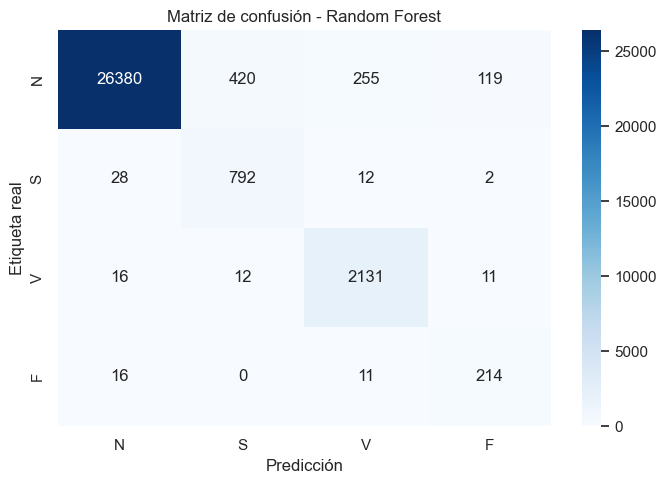

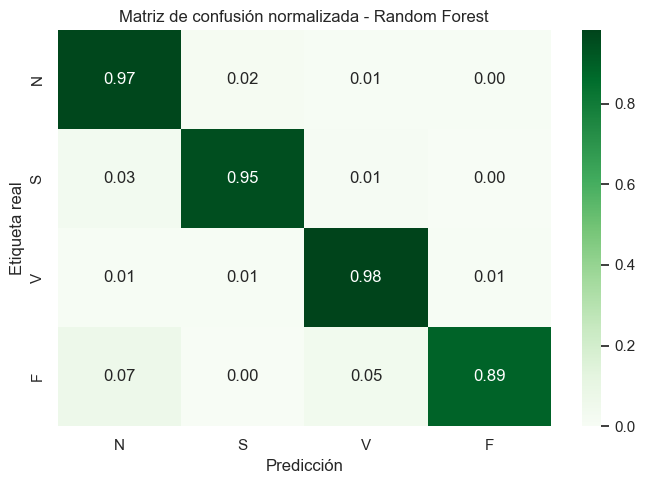

In [14]:
cm = confusion_matrix(y_test, best_predictions, labels=labels_present)
cm_normalized = confusion_matrix(y_test, best_predictions, labels=labels_present, normalize="true")

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_present, yticklabels=labels_present)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "random_forest_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens", xticklabels=labels_present, yticklabels=labels_present)
plt.title(f"Matriz de confusión normalizada - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "random_forest_confusion_matrix_normalized.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Guardado de resultados

In [15]:
OUTPUT_DIR.mkdir(exist_ok=True)

results_path = OUTPUT_DIR / "model_comparison_results.csv"
results_df.to_csv(results_path, index=False)
print(f"Resultados guardados en: {results_path}")

Resultados guardados en: outputs/model_comparison_results.csv
